In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# CELL 2. Khai báo path

YOLO_DIR = Path("/content/drive/MyDrive/Durian_Dataset/durian_yolo_cls_no_aug")
SAVE_DIR = Path("/content/drive/MyDrive/Train_Durian/MobileNetV1")

RUN_NAME = "mobilenetv1_no_aug_e30"

classes = ["Unripe", "Ripe", "Overripe"]

SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", YOLO_DIR.exists())
print("Train exists:", (YOLO_DIR / "train").exists())
print("Val exists:", (YOLO_DIR / "val").exists())
print("Test exists:", (YOLO_DIR / "test").exists())

Dataset exists: True
Train exists: True
Val exists: True
Test exists: True


In [4]:
# CELL 3. Cấu hình train

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 30
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [5]:
# CELL 4. Load dataset

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    YOLO_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
    class_names=classes
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    YOLO_DIR / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
    class_names=classes
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    YOLO_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
    class_names=classes
)

print("Class names:", train_ds.class_names)

Found 1879 files belonging to 3 classes.
Found 432 files belonging to 3 classes.
Found 407 files belonging to 3 classes.
Class names: ['Unripe', 'Ripe', 'Overripe']


In [6]:
# CELL 5. Preprocess + Prefetch

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(AUTOTUNE)

In [7]:
# CELL 6. Build MobileNetV1 model

base_model = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)

outputs = Dense(
    len(classes),
    activation="softmax"
)(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,231,939 (12.33 MB)

 Trainable params: 3,210,051 (12.25 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [8]:
# CELL 7. Callbacks

BEST_MODEL_PATH = SAVE_DIR / "mobilenetv1_best.keras"
LAST_MODEL_PATH = SAVE_DIR / "mobilenetv1_last.keras"
LOG_PATH = SAVE_DIR / "training_log.csv"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(
        filename=str(LOG_PATH),
        append=False
    )
]

In [9]:
# CELL 8. Train MobileNetV1
# 30 epochs, no augment, early stopping

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

runtime_sec = time.time() - start_time

model.save(LAST_MODEL_PATH)

print(f"Training runtime: {runtime_sec:.2f} seconds")
print("Best model saved to:", BEST_MODEL_PATH)
print("Last model saved to:", LAST_MODEL_PATH)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.7265 - loss: 0.8912 
Epoch 1: val_accuracy improved from None to 0.75000, saving model to /content/drive/MyDrive/Train_Durian/MobileNetV1/mobilenetv1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Train_Durian/MobileNetV1/mobilenetv1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 1087s 21s/step - accuracy: 0.8073 - loss: 0.6338 - val_accuracy: 0.7500 - val_loss: 3.7116
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9020 - loss: 0.2582 
Epoch 2: val_accuracy did not improve from 0.75000
30/30 ━━━━━━━━━━━━━━━━━━━━ 422s 14s/step - accuracy: 0.9159 - loss: 0.2209 - val_accuracy: 0.7500 - val_loss: 2.2500
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9568 - loss: 0.1174 
Epoch 3: val_accuracy improved from 0.75000 to 0.86343, saving model to /content/drive/MyDrive/Train_Durian/MobileNetV1/mobilenetv1_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Train_Durian

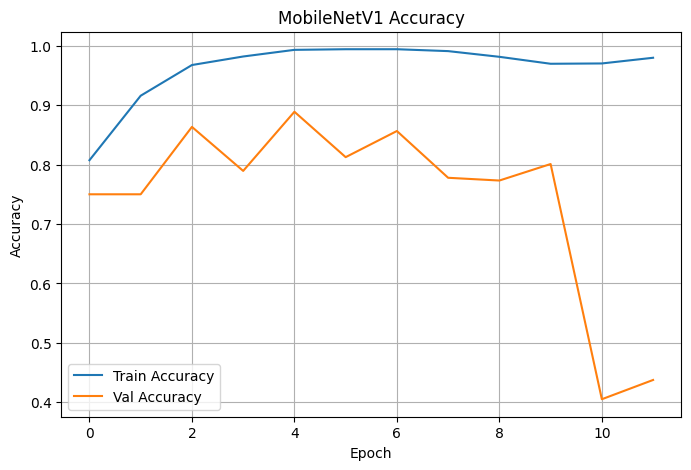

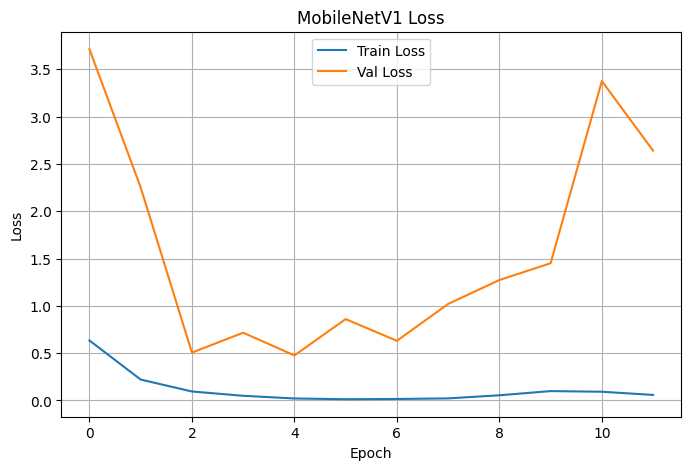

In [10]:
# =====================================================
# CELL 9. Vẽ biểu đồ Accuracy và Loss
# =====================================================
history_df = pd.DataFrame(history.history)
history_df.to_csv(SAVE_DIR / "history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Val Accuracy")
plt.title("MobileNetV1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Val Loss")
plt.title("MobileNetV1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# =====================================================
# CELL 10. Hàm đánh giá Val/Test
# Có Accuracy, Balanced Acc, Macro, Weighted
# =====================================================
def evaluate_dataset(model, dataset, dataset_name="Test"):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)

        y_prob.extend(probs)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision_macro = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    recall_macro = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    f1_macro = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall_weighted = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1_weighted = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print("=" * 60)
    print(f"{dataset_name} Results")
    print("=" * 60)
    print(f"Accuracy            : {acc:.4f}")
    print(f"Balanced Accuracy   : {bal_acc:.4f}")
    print(f"Precision Macro     : {precision_macro:.4f}")
    print(f"Recall Macro        : {recall_macro:.4f}")
    print(f"F1 Macro            : {f1_macro:.4f}")
    print(f"Precision Weighted  : {precision_weighted:.4f}")
    print(f"Recall Weighted     : {recall_weighted:.4f}")
    print(f"F1 Weighted         : {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "dataset": dataset_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

Validation Results
Accuracy            : 0.8889
Balanced Accuracy   : 0.7532
Precision Macro     : 0.7659
Recall Macro        : 0.7532
F1 Macro            : 0.7589
Precision Weighted  : 0.8855
Recall Weighted     : 0.8889
F1 Weighted         : 0.8869

Classification Report:
              precision    recall  f1-score   support

      Unripe     0.9574    0.9722    0.9648       324
        Ripe     0.6735    0.6875    0.6804        48
    Overripe     0.6667    0.6000    0.6316        60

    accuracy                         0.8889       432
   macro avg     0.7659    0.7532    0.7589       432
weighted avg     0.8855    0.8889    0.8869       432



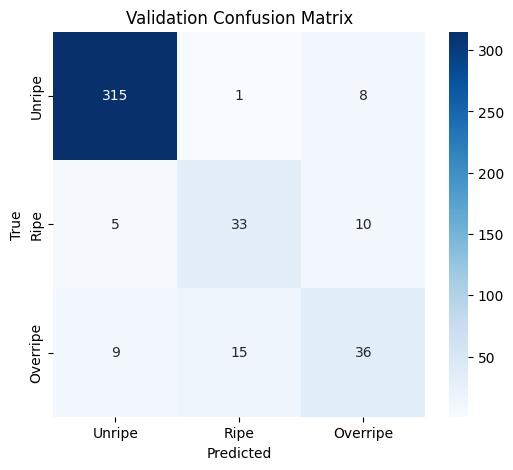

Test Results
Accuracy            : 0.8943
Balanced Accuracy   : 0.8316
Precision Macro     : 0.7886
Recall Macro        : 0.8316
F1 Macro            : 0.7884
Precision Weighted  : 0.9191
Recall Weighted     : 0.8943
F1 Weighted         : 0.8995

Classification Report:
              precision    recall  f1-score   support

      Unripe     0.9794    0.9532    0.9661       299
        Ripe     0.8704    0.6528    0.7460        72
    Overripe     0.5161    0.8889    0.6531        36

    accuracy                         0.8943       407
   macro avg     0.7886    0.8316    0.7884       407
weighted avg     0.9191    0.8943    0.8995       407



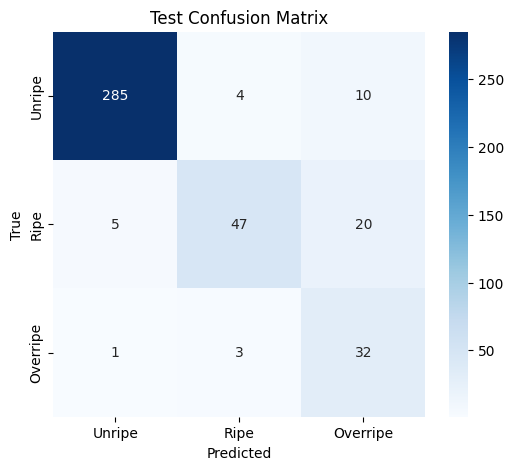

,dataset,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Validation,0.888889,0.753241,0.765861,0.753241,0.758923,0.885508,0.888889,0.886904
1,Test,0.894349,0.831615,0.788627,0.831615,0.788398,0.919121,0.894349,0.899481


In [15]:
# =====================================================
# CELL 11. Đánh giá Validation và Test
# =====================================================
val_metrics = evaluate_dataset(model, val_ds, "Validation")
test_metrics = evaluate_dataset(model, test_ds, "Test")

metrics_df = pd.DataFrame([val_metrics, test_metrics])
metrics_df.to_csv(SAVE_DIR / "mobilenetv1_metrics.csv", index=False)

display(metrics_df)

In [13]:
# =====================================================
# CELL 12. Lưu summary
# =====================================================
summary = {
    "model": "MobileNetV1",
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "imgsz": 224,
    "batch": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": 0.001,
    "augmentation": "No",
    "pretrained": "ImageNet",
    "runtime_sec": runtime_sec,
    "save_dir": str(SAVE_DIR)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(SAVE_DIR / "mobilenetv1_summary.csv", index=False)

display(summary_df)

,model,epochs,patience,imgsz,batch,optimizer,lr,augmentation,runtime_sec,save_dir
0,MobileNetV1,30,7,224,64,Adam,0.001,No,5849.201342,/content/drive/MyDrive/Train_Durian/MobileNetV1
